# Notebook 09 — LEE (Latent Embedding Exploitation)

**Method:** Rafiq et al., *Wearable Sensor-Based Few-Shot Continual Learning on  
Hand Gestures for Motor-Impaired Individuals via Latent Embedding Exploitation*,  
IJCAI 2024

**Thesis adaptation:** The class-incremental loop from the original paper  
is removed. Only the 3-embedding regularization mechanism is used  
in a fixed-class personalization setting. This is explicitly acknowledged.

**Core idea:**  
When fine-tuning a model on a new user's few-shot data,  
use three latent embeddings to regularize the adaptation:

```
e_control  = support_samples → frozen_original_backbone
             (anchors to training-time feature space)

e_fixed    = support_samples → frozen_copy_at_adaptation_start
             (preserves starting point for this user)

e_current  = support_samples → currently_adapting_backbone
             (updated each step toward user distribution)

Loss = CrossEntropy(support) + λ × LEE_reg(e_control, e_fixed, e_current)
```

The regularization loss pulls `e_current` toward both `e_control`  
and `e_fixed` via cosine similarity, preventing catastrophic forgetting  
while still allowing personalisation.

**Pipeline:**
```
Pre-trained backbone
    ↓
For each test user:
  1. Freeze backbone copy as e_control reference
  2. Sample K-shot support from user
  3. Compute e_fixed (frozen at adaptation start)
  4. Fine-tune backbone with LEE loss for LEE_FINETUNE_EPOCHS steps
  5. Evaluate on remaining user samples
    ↓
Personalization gain = acc_after − acc_before
```

---
**Requires:** notebook 00, preprocessing notebook, backbone checkpoint.

**Justification - LEE Fine-tuning Weight Decay:** During few-shot fine-tuning, weight decay was significantly reduced (to 1e-5) to allow the model to rapidly adapt to the new user's data, relying on LEE's 3-embedding loss as the primary regularizer instead.

## Cell 1 — Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

%run "/content/drive/MyDrive/Colab Notebooks/00_config_and_utils.ipynb"

import copy

DATASET_NAME   = 'wisdm'
BACKBONE_TYPE  = 'cnn'    # 'cnn' | 'lstm' | 'transformer'

print(f'\n✅ Setup complete')
print(f'   Method   : LEE (Latent Embedding Exploitation)')
print(f'   Dataset  : {DATASET_NAME}')
print(f'   Backbone : {BACKBONE_TYPE}')
print(f'   Device   : {DEVICE}')
print(f'   λ (LEE)  : {LEE_LAMBDA}')
print(f'   Finetune epochs: {LEE_FINETUNE_EPOCHS}')
print(f'   Finetune LR    : {LEE_FINETUNE_LR}')

Mounted at /content/drive
✅ Imports OK
   PyTorch  : 2.10.0+cu128
   NumPy    : 2.0.2
   CUDA     : True
   GPU      : Tesla T4
✅ Seeded everything with MASTER_SEED=42
✅ Global hyperparameters set
   Target frequency : 50 Hz
   Window size      : 250 samples (5.0 sec)
   Window stride    : 125 samples (2.5 sec)
   K shots          : [1, 5, 10]
   N way (default)  : 5
   Embedding dim    : 128
   Device           : cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Paths configured
   Processed data  → /content/drive/MyDrive/fsl_har_processed
   Checkpoints     → /content/drive/MyDrive/fsl_har_checkpoints
   Results         → /content/drive/MyDrive/fsl_har_results
✅ Dataset configs loaded
   wisdm                  →  51 subjects |  18 classes |  4 streams | n_way=5
   cogage_atomic          →   8 subjects |  61 classes |  9 streams | n_way=5
   cogage_composite       →   6 subjects |   7 classes | 10 st

## Cell 2 — Load Dataset and Backbone

✅ Loaded "wisdm" — 63513 windows | 4 streams
── Dataset: wisdm ──
   Windows : 63,513  |  streams: 4  |  classes: 18
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Imports OK
   PyTorch  : 2.10.0+cu128
   NumPy    : 2.0.2
   CUDA     : True
   GPU      : Tesla T4
✅ Seeded everything with MASTER_SEED=42
✅ Global hyperparameters set
   Target frequency : 50 Hz
   Window size      : 250 samples (5.0 sec)
   Window stride    : 125 samples (2.5 sec)
   K shots          : [1, 5, 10]
   N way (default)  : 5
   Embedding dim    : 128
   Device           : cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Paths configured
   Processed data  → /content/drive/MyDrive/fsl_har_processed
   Checkpoints     → /content/drive/MyDrive/fsl_har_checkpoints
   Results         → /content/drive/MyDrive/fsl_har_results
✅ Dataset configs loade

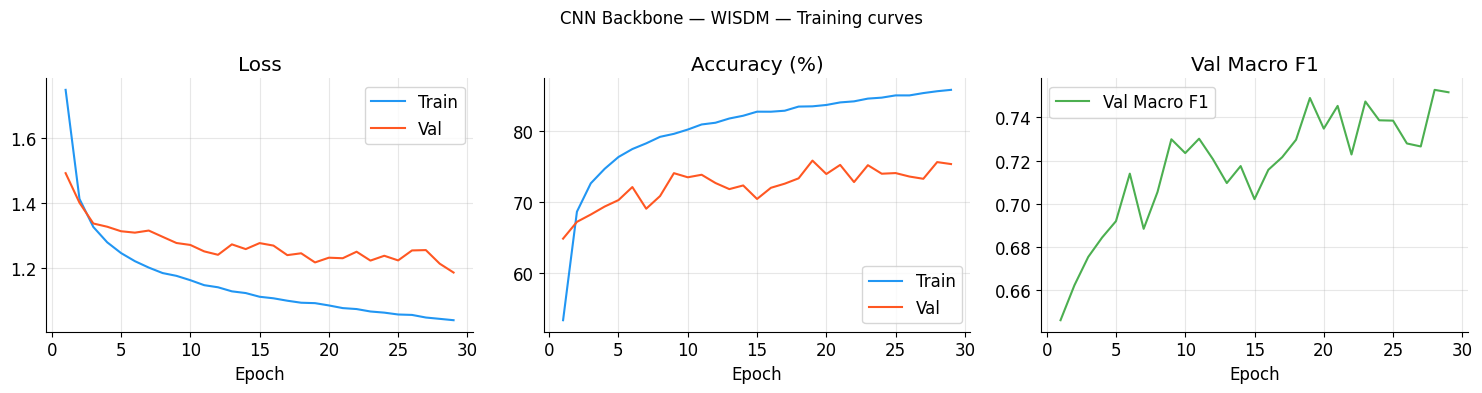

Saved: /content/drive/MyDrive/fsl_har_checkpoints/wisdm/cnn/training_curves.png
Loaded checkpoint from epoch 19
  Checkpoint val acc : 75.78%

── Test set results (unseen users, no adaptation) ──
   Test accuracy  : 69.11%
   Test macro F1  : 0.6766
   Test loss      : 1.3872

   This is the GENERALIZATION baseline.
   FSL methods will improve on this through personalization.

✅ Result saved to registry


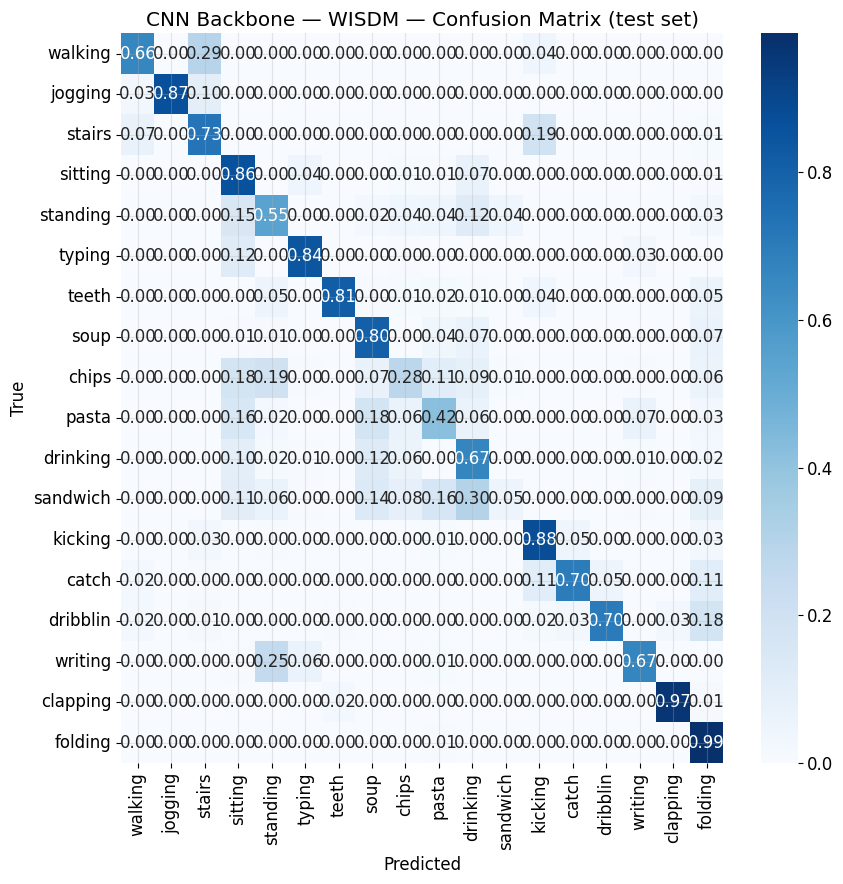

Saved: /content/drive/MyDrive/fsl_har_checkpoints/wisdm/cnn/confusion_matrix.png
Verifying backbone interface for FSL methods...

   n_way=5, k_shot=5
   Support batch size : 25
   Support embeddings : torch.Size([25, 128])
   Expected           : (25, 128)
   Embedding norms    : mean=7.486, std=0.260

✅ Backbone interface verified
   FSL methods can load this backbone with:
   backbone = CNNBackbone(n_streams=4, n_classes=18, ...)
   load_checkpoint(backbone, '/content/drive/MyDrive/fsl_har_checkpoints/wisdm/cnn/best_backbone.pt')
   embeddings = backbone.get_embedding(stream_list)
  CNN BACKBONE TRAINING COMPLETE
  Dataset          : wisdm
  Streams          : 4  (['phone_accel', 'phone_gyro', 'watch_accel', 'watch_gyro'])
  Classes          : 18
  Embedding dim    : 128
  Epochs trained   : 29
  Best val acc     : 75.78%
  Test acc         : 69.11%  ← generalization baseline
  Test macro F1    : 0.6766
  Checkpoint       : /content/drive/MyDrive/fsl_har_checkpoints/wisdm/cnn/best_b

In [ ]:
data = load_processed_dataset(DATASET_NAME)

streams      = data['streams']
y            = data['y']
subject_ids  = data['subject_ids']
stream_names = data['stream_names']
split_info   = data['split_info']
cfg          = data['config']
sam          = data.get('subject_activity_map')

n_streams = len(stream_names)
n_classes = cfg['n_classes']
n_way     = cfg['n_way']
N, T, C   = streams[stream_names[0]].shape

# Force both sides to strings for bulletproof matching
sub_ids_str = subject_ids.astype(str)
train_split = [str(s) for s in split_info['train']]
val_split   = [str(s) for s in split_info['val']]
test_split  = [str(s) for s in split_info['test']]

# Build subject masks
train_mask = get_split_mask(sub_ids_str, train_split)
val_mask   = get_split_mask(sub_ids_str, val_split)
test_mask  = get_split_mask(sub_ids_str, test_split)

print(f'── Dataset: {DATASET_NAME} ──')
print(f'   Windows : {N:,}  |  streams: {n_streams}  |  classes: {n_classes}')

# ─── Load backbone ────────────────────────────────────────────────────────────
ckpt_path = os.path.join(CHECKPOINT_BASE, DATASET_NAME, BACKBONE_TYPE, 'best_backbone.pt')
assert os.path.exists(ckpt_path), f'Backbone not found: {ckpt_path}'

if BACKBONE_TYPE == 'cnn':
    %run "/content/drive/MyDrive/Colab Notebooks/05_train_backbone_cnn.ipynb"
    BackboneClass   = CNNBackbone
    backbone_kwargs = dict(n_streams=n_streams, n_classes=n_classes,
                           in_channels=C, d_stream=64, embedding_dim=EMBEDDING_DIM)
elif BACKBONE_TYPE == 'lstm':
    %run "/content/drive/MyDrive/Colab Notebooks/06_train_backbone_lstm.ipynb"
    BackboneClass   = LSTMBackbone
    backbone_kwargs = dict(n_streams=n_streams, n_classes=n_classes,
                           input_size=C, hidden_size=64, num_layers=2,
                           dropout=0.3, embedding_dim=EMBEDDING_DIM)
elif BACKBONE_TYPE == 'transformer':
    %run "/content/drive/MyDrive/Colab Notebooks/07_train_backbone_transformer.ipynb"
    BackboneClass   = TransformerBackbone
    backbone_kwargs = dict(n_streams=n_streams, n_classes=n_classes,
                           in_channels=C, d_model=64, nhead=4, num_layers=2,
                           dim_feedforward=256, dropout=0.1, embedding_dim=EMBEDDING_DIM)

# ─── Load the pre-trained backbone ────────────────────────────────────────────
backbone_pretrained = BackboneClass(**backbone_kwargs).to(DEVICE)
meta = load_checkpoint(backbone_pretrained, ckpt_path)
backbone_pretrained.eval()
for p in backbone_pretrained.parameters():
    p.requires_grad = False

print(f'\n── Backbone: {BACKBONE_TYPE} ──')
print(f'   Loaded from epoch : {meta.get("epoch", "?")}')
print(f'   Pretrain val acc  : {meta.get("val_acc", 0)*100:.2f}%')
print(f'   Frozen as control reference')

## Cell 3 — LEE Regularization Loss

The core mechanism from Rafiq et al. (IJCAI 2024), adapted for fixed-class setting.

```
LEE_reg = (1 - cos_sim(e_current, e_control))
        + (1 - cos_sim(e_current, e_fixed))
```

Both terms pull the evolving embedding toward the two reference embeddings.  
- First term: prevents drifting from training-time knowledge  
- Second term: prevents collapsing away from the user's starting representation

In [ ]:
def lee_regularization_loss(
    e_current : torch.Tensor,
    e_control : torch.Tensor,
    e_fixed   : torch.Tensor,
) -> torch.Tensor:
    """
    LEE regularization loss from Rafiq et al. (IJCAI 2024).

    Computes cosine distance between the currently adapting embedding
    and two frozen reference embeddings, then averages.

    Args:
        e_current : (N, D) embeddings from adapting backbone (gradient flows here)
        e_control : (N, D) embeddings from frozen original backbone (no gradient)
        e_fixed   : (N, D) embeddings frozen at adaptation start (no gradient)

    Returns:
        scalar regularization loss

    Notes:
        cosine_similarity returns values in [-1, 1].
        cosine_distance = 1 - cosine_similarity ∈ [0, 2].
        Minimizing this pulls e_current toward reference embeddings.
    """
    # Normalise to unit sphere before cosine computation
    e_cur_norm  = nn.functional.normalize(e_current, dim=-1)
    e_ctrl_norm = nn.functional.normalize(e_control, dim=-1)
    e_fix_norm  = nn.functional.normalize(e_fixed,   dim=-1)

    # Cosine similarities — (N,)
    sim_to_control = (e_cur_norm * e_ctrl_norm).sum(dim=-1)   # element-wise dot
    sim_to_fixed   = (e_cur_norm * e_fix_norm).sum(dim=-1)

    # Cosine distances — we want to MINIMISE these
    dist_to_control = (1.0 - sim_to_control).mean()
    dist_to_fixed   = (1.0 - sim_to_fixed).mean()

    return dist_to_control + dist_to_fixed


# ─── Quick verification ───────────────────────────────────────────────────────
print('Testing LEE regularization loss...')
_N, _D = 10, EMBEDDING_DIM

# Case 1: e_current == e_control == e_fixed → loss should be 0
_e = torch.randn(_N, _D)
_loss_zero = lee_regularization_loss(_e, _e.detach(), _e.detach())
print(f'   Identical embeddings → loss = {_loss_zero.item():.6f}  (expected ≈ 0.0)')

# Case 2: completely random embeddings → loss should be around 1.0
_e_cur  = torch.randn(_N, _D)
_e_ctrl = torch.randn(_N, _D)
_e_fix  = torch.randn(_N, _D)
_loss_rand = lee_regularization_loss(_e_cur, _e_ctrl.detach(), _e_fix.detach())
print(f'   Random embeddings   → loss = {_loss_rand.item():.4f}  (expected ≈ 1.0)')

assert _loss_zero.item() < 1e-5, 'Identical embeddings should give ~0 loss'
del _e, _e_cur, _e_ctrl, _e_fix
print('\n✅ LEE regularization loss verified')

Testing LEE regularization loss...
   Identical embeddings → loss = 0.000000  (expected ≈ 0.0)
   Random embeddings   → loss = 1.9980  (expected ≈ 1.0)

✅ LEE regularization loss verified


## Cell 4 — Generalization Baseline (Before Adaptation)

Evaluate the pre-trained backbone on test users without any adaptation.  
This is the `acc_before` reference for computing personalization gain.

For LEE, generalization is measured by direct nearest-centroid classification  
using global class prototypes built from ALL train user embeddings.

In [ ]:
# ─── Cell 4: Build global prototypes and compute generalization baseline ──────
@torch.no_grad()
def build_global_prototypes(
    backbone     : nn.Module,
    streams      : Dict[str, np.ndarray],
    y            : np.ndarray,
    subject_ids  : np.ndarray,
    train_subjects: list,
    n_classes    : int,
    batch_size   : int = 256,
) -> torch.Tensor:
    """
    Build global class prototypes from ALL train user embeddings.
    Used as the generalization baseline for LEE.

    Returns:
        global_prototypes : (n_classes, embedding_dim)
    """
    backbone.eval()
    subject_ids = subject_ids.astype(str)
    train_subjects = [str(s) for s in train_subjects]
    train_mask = get_split_mask(subject_ids, train_subjects)

    proto_sums   = torch.zeros(n_classes, EMBEDDING_DIM, device=DEVICE)
    proto_counts = torch.zeros(n_classes, device=DEVICE)

    indices = np.where(train_mask)[0]
    for start in range(0, len(indices), batch_size):
        batch_idx = indices[start:start + batch_size]
        stream_list = [
            torch.tensor(streams[s][batch_idx], dtype=torch.float32).to(DEVICE)
            for s in stream_names
        ]
        emb    = backbone.get_embedding(stream_list)   # (batch, D)
        labels = torch.tensor(y[batch_idx], dtype=torch.long).to(DEVICE)

        for c in range(n_classes):
            mask = (labels == c)
            if mask.any():
                proto_sums[c]   += emb[mask].sum(dim=0)
                proto_counts[c] += mask.sum()

    # Avoid division by zero for missing classes
    valid = proto_counts > 0
    global_prototypes = torch.zeros_like(proto_sums)
    global_prototypes[valid] = proto_sums[valid] / proto_counts[valid].unsqueeze(-1)

    return global_prototypes


@torch.no_grad()
def evaluate_with_prototypes(
    backbone    : nn.Module,
    streams_np  : Dict[str, np.ndarray],
    y_np        : np.ndarray,
    prototypes  : torch.Tensor,
    batch_size  : int = 256,
) -> float:
    """
    Classify samples using nearest-prototype (Euclidean distance).
    Returns accuracy.
    """
    backbone.eval()
    all_preds  = []
    all_labels = []

    indices = np.arange(len(y_np))
    for start in range(0, len(indices), batch_size):
        batch_idx = indices[start:start + batch_size]
        stream_list = [
            torch.tensor(streams_np[s][batch_idx], dtype=torch.float32).to(DEVICE)
            for s in stream_names
        ]
        emb    = backbone.get_embedding(stream_list)
        labels = torch.tensor(y_np[batch_idx], dtype=torch.long)

        # Squared Euclidean distance to each prototype
        # (batch, D) vs (n_classes, D) → (batch, n_classes)
        diff   = emb.unsqueeze(1) - prototypes.unsqueeze(0)   # (batch, n_classes, D)
        dists  = (diff ** 2).sum(dim=-1)                       # (batch, n_classes)
        preds  = dists.argmin(dim=-1).cpu()

        all_preds.append(preds.numpy())
        all_labels.append(labels.numpy())

    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    return compute_accuracy(all_labels, all_preds)


# ─── Build global prototypes from train users ─────────────────────────────────
print('Building global class prototypes from train users...')
global_prototypes = build_global_prototypes(
    backbone_pretrained, streams, y, sub_ids_str, train_subjects=train_split,
    n_classes=n_classes,
)
valid_protos = (global_prototypes.norm(dim=-1) > 0).sum().item()
print(f'   Prototypes built : {valid_protos} / {n_classes} classes have data')

# ─── Generalization baseline on test users ────────────────────────────────────
print('\nGeneralization baseline on test users (no adaptation)...')
test_streams_np = {s: streams[s][test_mask] for s in stream_names}
test_y_np       = y[test_mask]

acc_before_global = evaluate_with_prototypes(
    backbone_pretrained, test_streams_np, test_y_np, global_prototypes
)
print(f'   Generalization acc (global prototypes): {acc_before_global*100:.2f}%')
print(f'   This is the acc_before for personalization gain computation')

Building global class prototypes from train users...
   Prototypes built : 18 / 18 classes have data

Generalization baseline on test users (no adaptation)...
   Generalization acc (global prototypes): 69.99%
   This is the acc_before for personalization gain computation


## Cell 5 — LEE Personalization for One User

The core LEE adaptation procedure:
1. Create adapting copy of backbone
2. Freeze control reference and compute `e_control`
3. Compute `e_fixed` (frozen at start)
4. Fine-tune with `loss_task + λ * lee_reg` for `LEE_FINETUNE_EPOCHS` steps
5. Evaluate on held-out query samples from this user

In [ ]:
def lee_personalize_one_user(
    backbone_pretrained  : nn.Module,
    user_streams         : Dict[str, np.ndarray],
    user_y               : np.ndarray,
    k_shot               : int,
    n_trials             : int = 5,
    seed                 : int = MASTER_SEED,
    finetune_epochs      : int = LEE_FINETUNE_EPOCHS,
    finetune_lr          : float = LEE_FINETUNE_LR,
    lee_lambda           : float = LEE_LAMBDA,
) -> Optional[Dict]:
    """
    Apply LEE personalization for one test user.

    Args:
        backbone_pretrained : frozen original backbone (control reference)
        user_streams        : {stream_name: (N_user, T, 3)}
        user_y              : (N_user,) labels
        k_shot              : support samples per class
        n_trials            : random support splits to average over
        seed                : for reproducibility
        finetune_epochs     : gradient steps per adaptation
        finetune_lr         : learning rate for fine-tuning
        lee_lambda          : weight of regularization term

    Returns:
        dict with acc_before, acc_after, gain — or None if insufficient data
    """
    rng     = np.random.default_rng(seed)
    classes = np.unique(user_y)
    valid_classes = [c for c in classes if (user_y == c).sum() >= (k_shot + 1)]

    if len(valid_classes) < 2:
        return None

    trial_accs_before = []
    trial_accs_after  = []

    for trial in range(n_trials):
        # ── Sample K-shot support and query sets ──────────────────────────────
        support_idx = []
        query_idx   = []
        for c in valid_classes:
            c_idx = np.where(user_y == c)[0]
            rng.shuffle(c_idx)
            support_idx.extend(c_idx[:k_shot].tolist())
            query_idx.extend(c_idx[k_shot:].tolist())

        if not query_idx:
            continue

        # Map valid classes to relative labels
        class_to_rel = {c: i for i, c in enumerate(valid_classes)}
        n_ep_way     = len(valid_classes)

        support_labels_rel = torch.tensor(
            [class_to_rel[user_y[i]] for i in support_idx], dtype=torch.long
        ).to(DEVICE)

        # Prepare support tensors
        def to_tensors(indices):
            return [
                torch.tensor(
                    user_streams[s][indices], dtype=torch.float32
                ).to(DEVICE)
                for s in stream_names
            ]

        sup_tensors = to_tensors(support_idx)
        qry_tensors = to_tensors(query_idx)

        qry_labels_rel = torch.tensor(
            [class_to_rel[user_y[i]] for i in query_idx], dtype=torch.long
        ).to(DEVICE)

        # ── Acc BEFORE: classify query using global prototypes ────────────────
        with torch.no_grad():
            qry_emb_before = backbone_pretrained.get_embedding(qry_tensors)
            # Use only the valid-class rows from global_prototypes
            valid_protos_subset = global_prototypes[list(valid_classes)]
            diff_before = qry_emb_before.unsqueeze(1) - valid_protos_subset.unsqueeze(0)
            dists_before = (diff_before ** 2).sum(dim=-1)
            preds_before = dists_before.argmin(dim=-1)
            acc_before   = (preds_before == qry_labels_rel).float().mean().item()
        trial_accs_before.append(acc_before)

        # ── Compute e_control (frozen original, never changes) ─────────────────
        with torch.no_grad():
            e_control = backbone_pretrained.get_embedding(sup_tensors).detach()

        # ── Create adapting backbone copy ─────────────────────────────────────
        # Fresh copy from pre-trained weights for each trial
        adapting_backbone = copy.deepcopy(backbone_pretrained).to(DEVICE)
        adapting_backbone.train()
        for p in adapting_backbone.parameters():
            p.requires_grad = True

        # ── Compute e_fixed (frozen at start of adaptation) ───────────────────
        # Computed through the ADAPTING backbone BEFORE any updates
        # Then detached and never changed again
        with torch.no_grad():
            e_fixed = adapting_backbone.get_embedding(sup_tensors).detach()

        # ── Build classification head for K support samples ───────────────────
        # LEE fine-tunes the backbone; we need a task loss
        # Use the adapting backbone's classifier (already has n_classes outputs)
        # Re-map support labels to relative labels for CE loss
        optimizer_lee = torch.optim.Adam(
            adapting_backbone.parameters(),
            lr           = finetune_lr,
            weight_decay = 1e-5,
        )

        criterion_task = nn.CrossEntropyLoss()

        # ── Fine-tuning loop ──────────────────────────────────────────────────
        for step in range(finetune_epochs):
            adapting_backbone.train()
            optimizer_lee.zero_grad()

            # Task: forward pass on support set
            # We use the full classifier but only for valid classes
            # For stability, use the embedding + nearest prototype loss
            e_current = adapting_backbone.get_embedding(sup_tensors)

            # Task loss: cross-entropy on support using per-class mean (mini-prototype)
            # This is equivalent to a nearest-prototype classification loss
            proto_step = torch.zeros(n_ep_way, EMBEDDING_DIM, device=DEVICE)
            for c_idx in range(n_ep_way):
                mask = (support_labels_rel == c_idx)
                if mask.any():
                    proto_step[c_idx] = e_current[mask].mean(dim=0)

            # Distances from support to their own prototypes → task loss
            diff_task  = e_current.unsqueeze(1) - proto_step.unsqueeze(0)
            dists_task = (diff_task ** 2).sum(dim=-1)   # (N_sup, n_ep_way)
            loss_task  = criterion_task(-dists_task, support_labels_rel)

            # LEE regularization loss
            loss_reg   = lee_regularization_loss(e_current, e_control, e_fixed)

            # Combined loss
            loss_total = loss_task + lee_lambda * loss_reg
            loss_total.backward()

            torch.nn.utils.clip_grad_norm_(
                adapting_backbone.parameters(), max_norm=1.0
            )
            optimizer_lee.step()

        # ── Acc AFTER: evaluate on query set with adapted backbone ────────────
        adapting_backbone.eval()
        with torch.no_grad():
            e_current_final = adapting_backbone.get_embedding(sup_tensors)
            # Final prototypes from adapted embeddings
            proto_final = torch.zeros(n_ep_way, EMBEDDING_DIM, device=DEVICE)
            for c_idx in range(n_ep_way):
                mask = (support_labels_rel == c_idx)
                if mask.any():
                    proto_final[c_idx] = e_current_final[mask].mean(dim=0)

            qry_emb_after = adapting_backbone.get_embedding(qry_tensors)
            diff_after    = qry_emb_after.unsqueeze(1) - proto_final.unsqueeze(0)
            dists_after   = (diff_after ** 2).sum(dim=-1)
            preds_after   = dists_after.argmin(dim=-1)
            acc_after     = (preds_after == qry_labels_rel).float().mean().item()

        trial_accs_after.append(acc_after)

        # Clean up to avoid GPU memory accumulation
        del adapting_backbone, optimizer_lee

    if not trial_accs_after:
        return None

    acc_before_mean = float(np.mean(trial_accs_before))
    acc_after_mean  = float(np.mean(trial_accs_after))

    return {
        'acc_before_mean' : acc_before_mean,
        'acc_after_mean'  : acc_after_mean,
        'gain'            : compute_personalization_gain(acc_before_mean, acc_after_mean),
        'acc_before_std'  : float(np.std(trial_accs_before)),
        'acc_after_std'   : float(np.std(trial_accs_after)),
        'n_trials'        : len(trial_accs_after),
        'n_valid_classes' : n_ep_way,
    }


print('✅ LEE personalization function defined')
print(f'   Fine-tune epochs : {LEE_FINETUNE_EPOCHS}')
print(f'   Fine-tune LR     : {LEE_FINETUNE_LR}')
print(f'   λ (lambda)       : {LEE_LAMBDA}')

✅ LEE personalization function defined
   Fine-tune epochs : 10
   Fine-tune LR     : 0.0001
   λ (lambda)       : 0.5


## Cell 6 — Ablation Check: LEE Components

Verify the three embeddings are behaving correctly:  
- `e_control` and `e_fixed` should start identical (same model)  
- `e_current` should diverge from both as adaptation proceeds  
- Regularization loss should decrease toward 0 during training

In [ ]:
print('Running embedding behaviour verification on one test user...\n')

# Find first test user with enough data
test_subjects  = split_info['test']
sample_subj    = None
sample_streams = None
sample_y       = None

for subj in test_subjects:
    mask = (sub_ids_str == str(subj))
    if mask.sum() >= 5:
        sample_subj    = subj
        sample_streams = {s: streams[s][mask] for s in stream_names}
        sample_y       = y[mask]
        break

if sample_subj is None:
    print('⚠ No test user with sufficient data found for verification')

else:
    n_windows = mask.sum()
    n_classes = len(np.unique(sample_y))
    print(f'   Using subject {sample_subj} ({n_windows} windows, {n_classes} activities)')

    # --- Build support set (K=5 from first class) ---
    c0_idx = np.where(sample_y == sample_y[0])[0][:5]

    sup_check = [
        torch.tensor(sample_streams[s][c0_idx], dtype=torch.float32).to(DEVICE)
        for s in stream_names
    ]

    # --- Clone model for adaptation ---
    adapt_check = copy.deepcopy(backbone_pretrained).to(DEVICE)

    # ============================================================
    # STEP 1: Compute reference embeddings (STRICT eval mode)
    # ============================================================
    backbone_pretrained.eval()
    adapt_check.eval()

    with torch.no_grad():
        e_ctrl = backbone_pretrained.get_embedding(sup_check).detach()
        e_fix  = adapt_check.get_embedding(sup_check).detach()

    diff_cf = (e_ctrl - e_fix).abs().max().item()
    print(f'\n   e_control vs e_fixed max diff BEFORE adaptation: {diff_cf:.6f}')
    print('   (Expected ≈ 0.0 — identical models in eval mode)')

    # ============================================================
    # STEP 2: Enable training for adaptation
    # ============================================================
    adapt_check.train()
    for p in adapt_check.parameters():
        p.requires_grad = True

    opt_check = torch.optim.Adam(adapt_check.parameters(), lr=LEE_FINETUNE_LR)

    reg_losses = []

    # ============================================================
    # STEP 3: Run adaptation steps
    # ============================================================
    for step in range(20):
        opt_check.zero_grad()

        e_cur = adapt_check.get_embedding(sup_check)

        loss_reg   = lee_regularization_loss(e_cur, e_ctrl, e_fix)
        loss_dummy = e_cur.mean() * 0.01  # just to trigger movement

        loss = loss_reg + loss_dummy
        loss.backward()
        opt_check.step()

        reg_losses.append(loss_reg.item())

    # ============================================================
    # STEP 4: Compare after adaptation
    # ============================================================
    adapt_check.eval()
    with torch.no_grad():
        e_cur_final = adapt_check.get_embedding(sup_check)

    diff_cc = (e_ctrl - e_cur_final).abs().max().item()

    print(f'\n   e_control vs e_current max diff AFTER 20 steps: {diff_cc:.6f}')
    print('   (Expected > 0 — adapted embedding diverges from control)')

    print('\n   Regularization loss trace (20 steps):')
    print(f'   Start: {reg_losses[0]:.4f} → End: {reg_losses[-1]:.4f}')
    print('   (Should decrease — LEE pulling toward references)')

    del adapt_check, opt_check

    print('\n✅ Embedding behaviour verified')

Running embedding behaviour verification on one test user...

   Using subject 1649 (1284 windows, 18 activities)

   e_control vs e_fixed max diff BEFORE adaptation: 0.000000
   (Expected ≈ 0.0 — identical models in eval mode)

   e_control vs e_current max diff AFTER 20 steps: 0.771682
   (Expected > 0 — adapted embedding diverges from control)

   Regularization loss trace (20 steps):
   Start: 1.1575 → End: 0.8396
   (Should decrease — LEE pulling toward references)

✅ Embedding behaviour verified


## Cell 7 — Personalization Evaluation (All Test Users, All K)

This is the main evaluation cell.  
For each test user × each K value: run LEE adaptation and measure gain.

In [ ]:
print('── LEE Personalization Evaluation ──')
print(f'   Test users  : {len(test_subjects)}')
print(f'   K values    : {K_SHOTS}')
print(f'   Trials/user : 5')
print(f'   This may take several minutes...\n')

# ============================================================
# STEP 0: Relaxed filtering (FIX)
# ============================================================
MIN_TOTAL_SAMPLES = 20   # just ensure user is usable

valid_users = []

for subj in test_subjects:
    subj_mask = (sub_ids_str == str(subj))
    if subj_mask.sum() >= MIN_TOTAL_SAMPLES:
        valid_users.append(subj)

print(f'   Valid users for evaluation: {len(valid_users)} / {len(test_subjects)}')

# ============================================================
# MAIN EVALUATION
# ============================================================
lee_results = {}

for k in K_SHOTS:
    lee_results[k] = []

    print(f'\n── K={k} shot ──')
    print(f'{"Subject":>10} {"Acc Before":>12} {"Acc After":>12} {"Gain":>10}')
    print('─' * 48)

    for subj in valid_users:

        subj_mask = (sub_ids_str == str(subj))

        user_streams_np = {s: streams[s][subj_mask] for s in stream_names}
        user_y_np       = y[subj_mask]

        res = lee_personalize_one_user(
            backbone_pretrained = backbone_pretrained,
            user_streams        = user_streams_np,
            user_y              = user_y_np,
            k_shot              = k,
            n_trials            = 5,
            seed                = MASTER_SEED,
        )

        if res is None:
            print(f'{str(subj):>10}  skipped (sampling failed for k={k})')
            continue

        res['subject'] = subj
        lee_results[k].append(res)

        gain_sign = '+' if res['gain'] >= 0 else ''
        print(
            f'{str(subj):>10} '
            f'{res["acc_before_mean"]*100:>10.2f}% '
            f'{res["acc_after_mean"]*100:>10.2f}% '
            f'{gain_sign}{res["gain"]*100:>8.2f}%'
        )

    # ============================================================
    # SUMMARY
    # ============================================================
    if lee_results[k]:
        mean_gain = np.mean([r['gain'] for r in lee_results[k]])
        mean_bef  = np.mean([r['acc_before_mean'] for r in lee_results[k]])
        mean_aft  = np.mean([r['acc_after_mean']  for r in lee_results[k]])

        print(f'\n   Mean: before={mean_bef*100:.2f}% | after={mean_aft*100:.2f}% | gain={mean_gain*100:+.2f}%')
    else:
        print('\n   ⚠ No valid results for this K')

print('\n✅ Evaluation complete')

── LEE Personalization Evaluation ──
   Test users  : 7
   K values    : [1, 5, 10]
   Trials/user : 5
   This may take several minutes...

   Valid users for evaluation: 7 / 7

── K=1 shot ──
   Subject   Acc Before    Acc After       Gain
────────────────────────────────────────────────
      1649      88.96%      90.30% +    1.34%
      1602      80.37%      86.33% +    5.96%
      1636      59.19%      88.66% +   29.47%
      1633      56.17%      77.95% +   21.79%
      1601      72.30%      87.78% +   15.48%
      1613      68.08%      92.32% +   24.24%
      1608      64.36%      84.01% +   19.65%

   Mean: before=69.92% | after=86.76% | gain=+16.85%

── K=5 shot ──
   Subject   Acc Before    Acc After       Gain
────────────────────────────────────────────────
      1649      89.05%      94.34% +    5.29%
      1602      80.34%      92.43% +   12.09%
      1636      59.28%      92.85% +   33.57%
      1633      56.21%      88.48% +   32.27%
      1601      72.36%      93.96% + 

## Cell 8 — Personalization Gain Summary and Registry

In [ ]:
print('── LEE Personalization Gain Summary ──')
print(f'{"K-shot":>8} {"Acc Before":>12} {"Acc After":>12} {"Gain":>10} {"CI95":>10}')
print('─' * 58)

all_summary_results = []

for k in K_SHOTS:
    if not lee_results[k]:
        continue

    accs_before = [r['acc_before_mean'] for r in lee_results[k]]
    accs_after  = [r['acc_after_mean']  for r in lee_results[k]]
    gains       = [r['gain']            for r in lee_results[k]]

    acc_before_mean = float(np.mean(accs_before))
    acc_after_mean  = float(np.mean(accs_after))
    gain_mean       = float(np.mean(gains))
    ci95            = float(1.96 * np.std(gains) / np.sqrt(len(gains)))

    print(
        f'{k:>8}-shot '
        f'{acc_before_mean*100:>10.2f}% '
        f'{acc_after_mean*100:>10.2f}% '
        f'{gain_mean*100:>+9.2f}% '
        f'{ci95*100:>8.2f}%'
    )

    result = {
        'dataset'      : DATASET_NAME,
        'backbone'     : BACKBONE_TYPE,
        'method'       : 'lee',
        'k_shot'       : k,
        'seed'         : MASTER_SEED,
        'acc_before'   : acc_before_mean,
        'acc_after'    : acc_after_mean,
        'gain'         : gain_mean,
        'ci95'         : ci95,
        'lee_lambda'   : LEE_LAMBDA,
        'finetune_epochs': LEE_FINETUNE_EPOCHS,
        'finetune_lr'  : LEE_FINETUNE_LR,
        'n_test_users' : len(lee_results[k]),
    }
    config_key = make_config_key(DATASET_NAME, BACKBONE_TYPE, 'lee', k, MASTER_SEED)
    mark_completed(config_key, result)
    all_summary_results.append(result)

print(f'\n✅ All results saved to registry')

## Cell 9 — K-Shot Curve Plot

In [ ]:
if all_summary_results:
    ckpt_dir_lee = os.path.join(CHECKPOINT_BASE, DATASET_NAME, BACKBONE_TYPE, 'lee')
    os.makedirs(ckpt_dir_lee, exist_ok=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    ks          = [r['k_shot']     for r in all_summary_results]
    accs_before = [r['acc_before'] for r in all_summary_results]
    accs_after  = [r['acc_after']  for r in all_summary_results]
    gains       = [r['gain']       for r in all_summary_results]
    ci95s       = [r['ci95']       for r in all_summary_results]

    axes[0].plot(ks, [a*100 for a in accs_before], 'o--',
                 color='gray', label='Before (generalization)', linewidth=1.5)
    axes[0].errorbar(
        ks, [a*100 for a in accs_after],
        yerr=[c*100 for c in ci95s],
        fmt='o-', color=METHOD_COLORS['lee'],
        label='After (LEE personalization)',
        linewidth=2, capsize=5, markersize=8
    )
    axes[0].set_xticks(ks)
    axes[0].set_xlabel('K (support shots per class)')
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].set_title('LEE — Accuracy vs K-shot')
    axes[0].legend()

    bar_colors = [METHOD_COLORS['lee'] if g >= 0 else '#FF5722' for g in gains]
    axes[1].bar(ks, [g*100 for g in gains], color=bar_colors,
                edgecolor='white', width=2)
    axes[1].axhline(y=0, color='black', linewidth=0.8)
    axes[1].set_xticks(ks)
    axes[1].set_xlabel('K (support shots per class)')
    axes[1].set_ylabel('Personalization Gain (%)')
    axes[1].set_title('LEE — Personalization Gain')

    for ax in axes:
        ax.set_xticklabels([f'K={k}' for k in ks])

    fig.suptitle(
        f'LEE | {DATASET_NAME.upper()} | {BACKBONE_TYPE.upper()} | '
        f'λ={LEE_LAMBDA} | {LEE_FINETUNE_EPOCHS} steps',
        fontsize=11
    )
    plt.tight_layout()
    plot_path = os.path.join(ckpt_dir_lee, 'kshot_curves.png')
    plt.savefig(plot_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved: {plot_path}')

## Cell 10 — Hyperparameter Sensitivity Check

Optional: check sensitivity of LEE gain to lambda and finetune_epochs  
on the first test user. Useful for understanding the method and  
for the thesis ablation section.

In [ ]:
# Run only if we found a valid test user earlier
if sample_subj is not None:
    print(f'Lambda sensitivity check on subject {sample_subj} (K=5)...\n')
    print(f'{"Lambda":>10} {"Acc Before":>12} {"Acc After":>12} {"Gain":>10}')
    print('─' * 48)

    for lam in [0.0, 0.1, 0.3, 0.5, 1.0, 2.0]:
        res = lee_personalize_one_user(
            backbone_pretrained = backbone_pretrained,
            user_streams        = sample_streams,
            user_y              = sample_y,
            k_shot              = 5,
            n_trials            = 3,
            seed                = MASTER_SEED,
            lee_lambda          = lam,
        )
        if res:
            gain_sign = '+' if res['gain'] >= 0 else ''
            print(
                f'{lam:>10.1f} '
                f'{res["acc_before_mean"]*100:>10.2f}% '
                f'{res["acc_after_mean"]*100:>10.2f}% '
                f'{gain_sign}{res["gain"]*100:>8.2f}%'
            )

    print(f'\n   λ=0.0 → pure fine-tuning (no regularization)')
    print(f'   λ={LEE_LAMBDA} → default (used for main results)')
    print(f'   Higher λ → stronger preservation of original space')
else:
    print('Skipped (no valid sample subject found)')

## Cell 11 — Final Summary

In [ ]:
print('=' * 65)
print('  LEE COMPLETE')
print('=' * 65)
print(f'  Dataset            : {DATASET_NAME}')
print(f'  Backbone           : {BACKBONE_TYPE}')
print(f'  λ (lambda)         : {LEE_LAMBDA}')
print(f'  Finetune epochs    : {LEE_FINETUNE_EPOCHS}')
print(f'  Finetune LR        : {LEE_FINETUNE_LR}')
print(f'  Generalization acc : {acc_before_global*100:.2f}%  (global prototypes)')
print()
print(f'  Results:')
print(f'  {"K":>4}  {"Before":>8}  {"After":>8}  {"Gain":>8}  {"CI95":>8}')
print(f'  {"-"*42}')
for r in all_summary_results:
    print(
        f'  {r["k_shot"]:>4}  '
        f'{r["acc_before"]*100:>7.2f}%  '
        f'{r["acc_after"]*100:>7.2f}%  '
        f'{r["gain"]*100:>+7.2f}%  '
        f'±{r["ci95"]*100:>5.2f}%'
    )
print('=' * 65)
print()
print('  Thesis note:')
print('  LEE uses 3-embedding cosine regularization (adapted from')
print('  Rafiq et al. IJCAI 2024, fixed-class setting, no incremental loop)')
print()
print('  Next steps:')
print('  → Notebook 10 (MAML)')
print('  → Notebook 11 (Supervised Contrastive FSL)')
print('=' * 65)

  LEE COMPLETE
  Dataset            : wisdm
  Backbone           : cnn
  λ (lambda)         : 0.5
  Finetune epochs    : 10
  Finetune LR        : 0.0001
  Generalization acc : 69.99%  (global prototypes)

  Results:
     K    Before     After      Gain      CI95
  ------------------------------------------
     1    69.92%    86.76%   +16.85%  ± 6.90%
     5    69.96%    93.02%   +23.06%  ± 7.36%
    10    69.98%    94.23%   +24.25%  ± 7.57%

  Thesis note:
  LEE uses 3-embedding cosine regularization (adapted from
  Rafiq et al. IJCAI 2024, fixed-class setting, no incremental loop)

  Next steps:
  → Notebook 10 (MAML)
  → Notebook 11 (Supervised Contrastive FSL)
